In [336]:
import polars as pl
import os 
import requests
import matplotlib.pyplot as plt
from datetime import datetime, timezone
import numpy as np

QUESTDB_ENDPOINT = "https://timeseriesdbfrancesco.dev.rd.areasciencepark.it"
def get_table_data(filename, query: str) -> pl.DataFrame:
    #filename = str(filename)
    #if os.path.exists(filename):
    #    return pl.read_ipc(filename)
    response = requests.get(f"{QUESTDB_ENDPOINT}/exec", params={"query": query},
                            verify=False, timeout=60)
    response.raise_for_status()
    payload = response.json()
    df = pl.DataFrame(payload["dataset"], schema=[c["name"] for c in payload["columns"]],
                      orient="row")
    if "timestamp" in df.columns:
        df = df.with_columns(
            pl.col("timestamp").str.strptime(pl.Datetime, "%Y-%m-%dT%H:%M:%S%.fZ", strict=False))
    #df.write_ipc(filename)
    return df

In [2]:
LCST_STATS_PATH = lambda model_name, gen_toks : f"./logs/stats_{model_name}_t{gen_toks}__stats_history.csv"
TOKS_STATS_PATH = lambda model_name, gen_toks : f"./logs/llm_stats_{model_name}_t{gen_toks}.csv"

GEN_TOKENS = [
    250,
    500,
    1000,
    2000,
    4000,
    8000
]

GEN_TOKENS = [str(n) for n in GEN_TOKENS]

MODELS = [
    "Qwen3.8",
    "Qwen3.6"
]

RESULTS = {}
for m in MODELS: 
    RESULTS[m] = {}
    for toks in GEN_TOKENS:
        RESULTS[m][toks] = {}

LCST = {}
TOKS_STATS = {}
# Read stats history for all models
for m in MODELS:
    LCST[m] = {}
    TOKS_STATS[m] = {}
    for toks in GEN_TOKENS:
        LCST[m][toks] = pl.read_csv(LCST_STATS_PATH(model_name=m, gen_toks=toks))
        TOKS_STATS[m][toks] = pl.read_csv(TOKS_STATS_PATH(model_name=m, gen_toks=toks))

for m in MODELS:
    for toks in GEN_TOKENS:
        LCST[m][toks] = LCST[m][toks].with_columns(
            pl.from_epoch(pl.col("Timestamp"), time_unit="s").alias("Datetime")
        )

In [392]:
obsBegin = min( LCST[m][toks]["Timestamp"].min() for m in MODELS for toks in GEN_TOKENS )
obsEnd = max( LCST[m][toks]["Timestamp"].max() for m in MODELS for toks in GEN_TOKENS )

def ts_to_questdb_dt_format(ts, delta_seconds):
    ts += delta_seconds
    dt = datetime.fromtimestamp(ts, tz=timezone.utc)
    second = dt.second if len(str(dt.second)) == 2 else '0' + str(dt.second)
    minute = dt.minute if len(str(dt.minute)) == 2 else '0' + str(dt.minute)
    hour = dt.hour     if len(str(dt.hour)) == 2 else '0' + str(dt.hour)
    day = dt.day       if len(str(dt.day)) == 2 else '0' + str(dt.day)
    month = dt.month   if len(str(dt.month)) == 2 else '0' + str(dt.month)
    ts = f"{dt.year}-{month}-{day}T{hour}:{minute}:{second}Z"
    return ts

def datetime_from_timestamp(ts):
    dt = datetime.fromtimestamp(ts, tz=timezone.utc)
    return dt

delta_seconds = 60
QUERIES = {
"nvidia_smi" : f"""
    SELECT timestamp, index, power_draw, utilization_memory, temperature_gpu, utilization_gpu
    FROM nvidia_smi
    WHERE '{ts_to_questdb_dt_format(obsBegin, -delta_seconds)}' < timestamp AND timestamp < '{ts_to_questdb_dt_format(obsEnd, +delta_seconds)}'
    """,
"ipmi_power" : f"""
    SELECT timestamp, value, host, psu_id, type, unit
    FROM ipmi_power
    WHERE 
        '{ts_to_questdb_dt_format(obsBegin, -delta_seconds)}' < timestamp AND timestamp < '{ts_to_questdb_dt_format(obsEnd, +delta_seconds)}'
        AND 1=1
""",
"cpu" : f"""
    SELECT timestamp, package_power_watt, ram_power_watt
    FROM turbostat
    WHERE 
        '{ts_to_questdb_dt_format(obsBegin, -delta_seconds)}' < timestamp AND timestamp < '{ts_to_questdb_dt_format(obsEnd, +delta_seconds)}'
        AND cpu='-'
"""
}


In [393]:
DB = {}
for key in QUERIES.keys():
    q = QUERIES[key]
    DB[key] = get_table_data("",q)
    DB[key] = DB[key].rename({"timestamp": "Datetime"})
    DB[key] = DB[key].with_columns(
    (pl.col("Datetime").dt.timestamp("us") // 1e6).alias("Timestamp")
)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/urllib3/connectionpool.py:1129: InsecureRequestWarning: Unverified HTTPS request is being made to host 'timeseriesdbfrancesco.dev.rd.areasciencepark.it'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/urllib3/connectionpool.py:1129: InsecureRequestWarning: Unverified HTTPS request is being made to host 'timeseriesdbfrancesco.dev.rd.areasciencepark.it'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/urllib3/connectionpool.py:1129: InsecureRequestWarning: Unverified HTTPS request is being made to host 'timeseriesdbfrancesco.dev.rd.areasciencepark.it'. 

# ------------------------------------------------------------<br>
## per essere sicuro cosa contiene ipmi_power
# ------------------------------------------------------------

In [394]:
df = DB["ipmi_power"]
hosts = set(df["host"])
pset = set(df["psu_id"])
print(pset)
print(hosts)

{'2', '4', '0', '5', '3', '6', '1'}
{'dgx005.hpc.rd.areasciencepark.it'}


[]

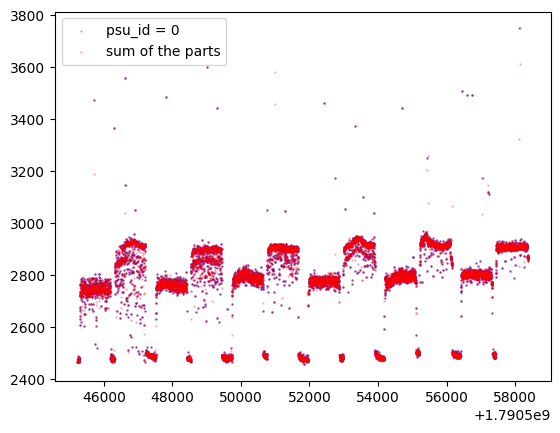

In [423]:
df = DB["ipmi_power"]
sm = None
for ps in pset:
    tmp = df.filter((pl.col("psu_id") == ps) & (pl.col("unit") == "W"))    
    xx = tmp["Timestamp"]
    yy = tmp["value"]
    if ps == '0':
        tt = yy
        plt.scatter(xx, yy, label="psu_id = 0",c="blue", s=0.4, alpha=0.3)
    else:
        if sm is None: sm = yy
        else:
            sm = sm + yy
plt.scatter(xx, sm, label="sum of the parts",c="red", s=0.4, alpha=0.3)
plt.legend()
plt.plot()


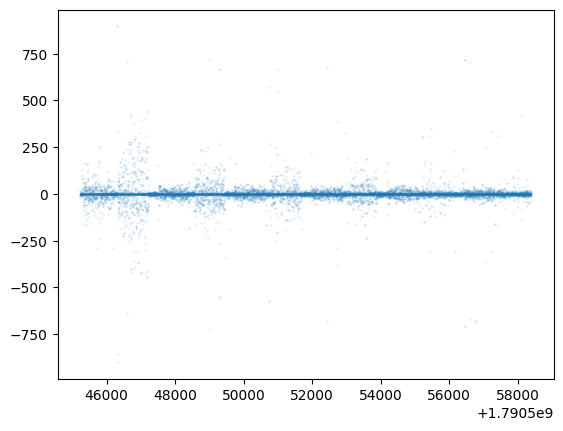

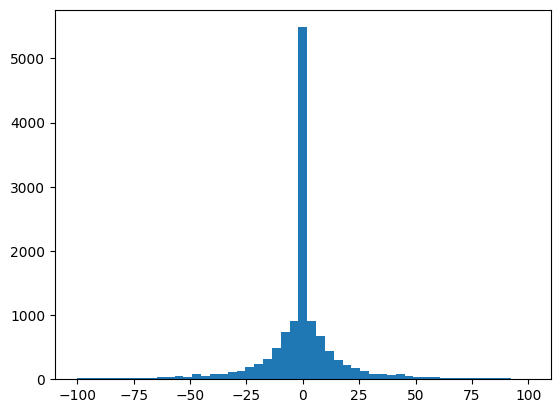

In [396]:
plt.scatter(xx, sm-tt, s=0.5, alpha=0.1)
plt.show()
plt.hist(sm-tt, bins=51, range=(-100,100))
plt.show()

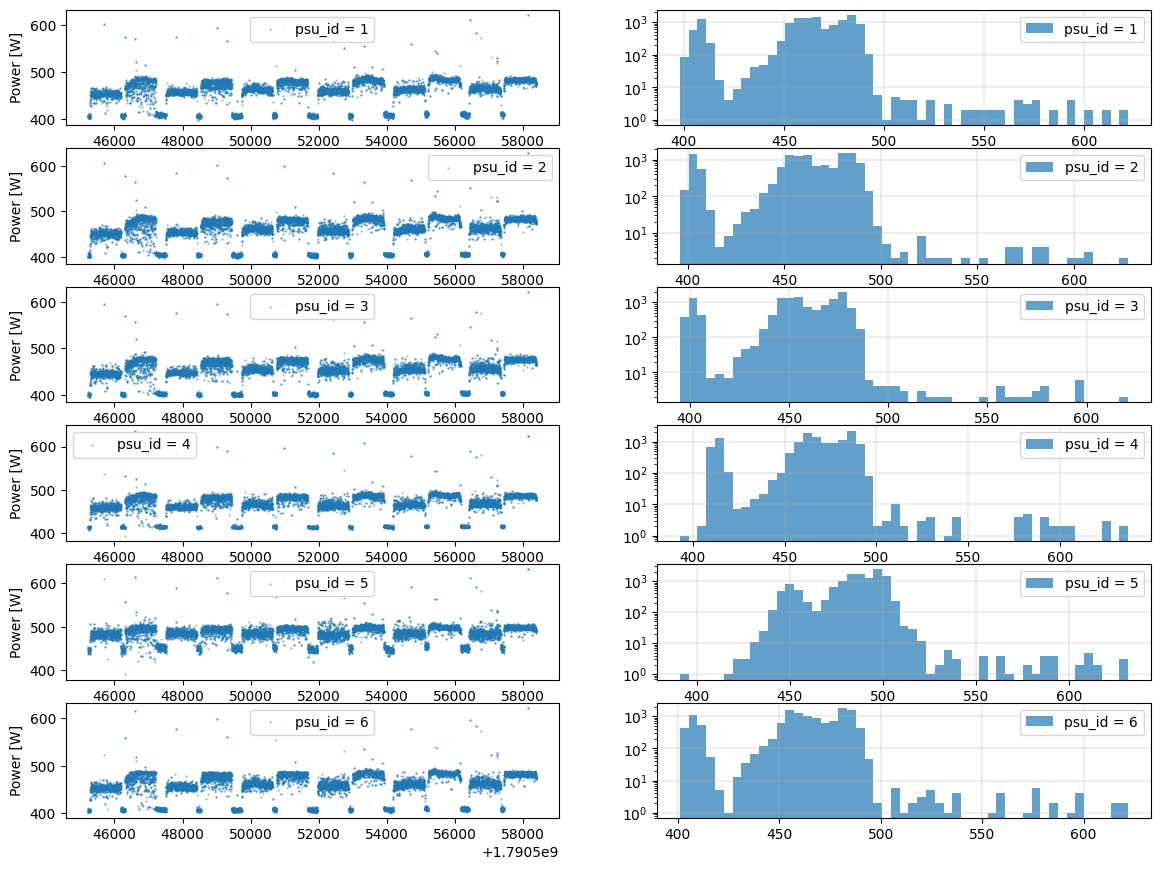

In [397]:
# Vediamo comunque come sono fatti i set di misure
fig, axes = plt.subplots(6, 2,
                         figsize=(14, 3.5 * 3),
                         sharex=False,
                         sharey=False)

for psu_id in range(1,7):
    ax = axes[psu_id-1][0]
    tmp = df.filter((pl.col("psu_id") == str(psu_id)) & (pl.col("unit") == "W"))    
    xx = tmp["Timestamp"]
    yy = tmp["value"]
    ax.set_ylabel("Power [W]")
    ax.scatter(xx, yy, label=f"psu_id = {psu_id}", s=0.3, alpha=0.5)
    ax.legend()
    # hist
    ax = axes[psu_id-1][1]
    ax.hist(yy, bins=51, label=f"psu_id = {psu_id}", alpha=0.7)
    ax.set_yscale("log")
    ax.grid(lw=0.3)
    ax.legend()
plt.show()

## => Prendo psu_id = '0' come il valore di sum( psu_id in {1,2,...,6} ) <br>

# --------------------------------------------------- <br>
## fine - qui sotto l'analisi e grafici per evitare allucinazioni
# ---------------------------------------------------

# FINDING OUT WHICH GPU IS USED DURING BENCHMARK <br>
### (here i assume only one is used and the others are idle)

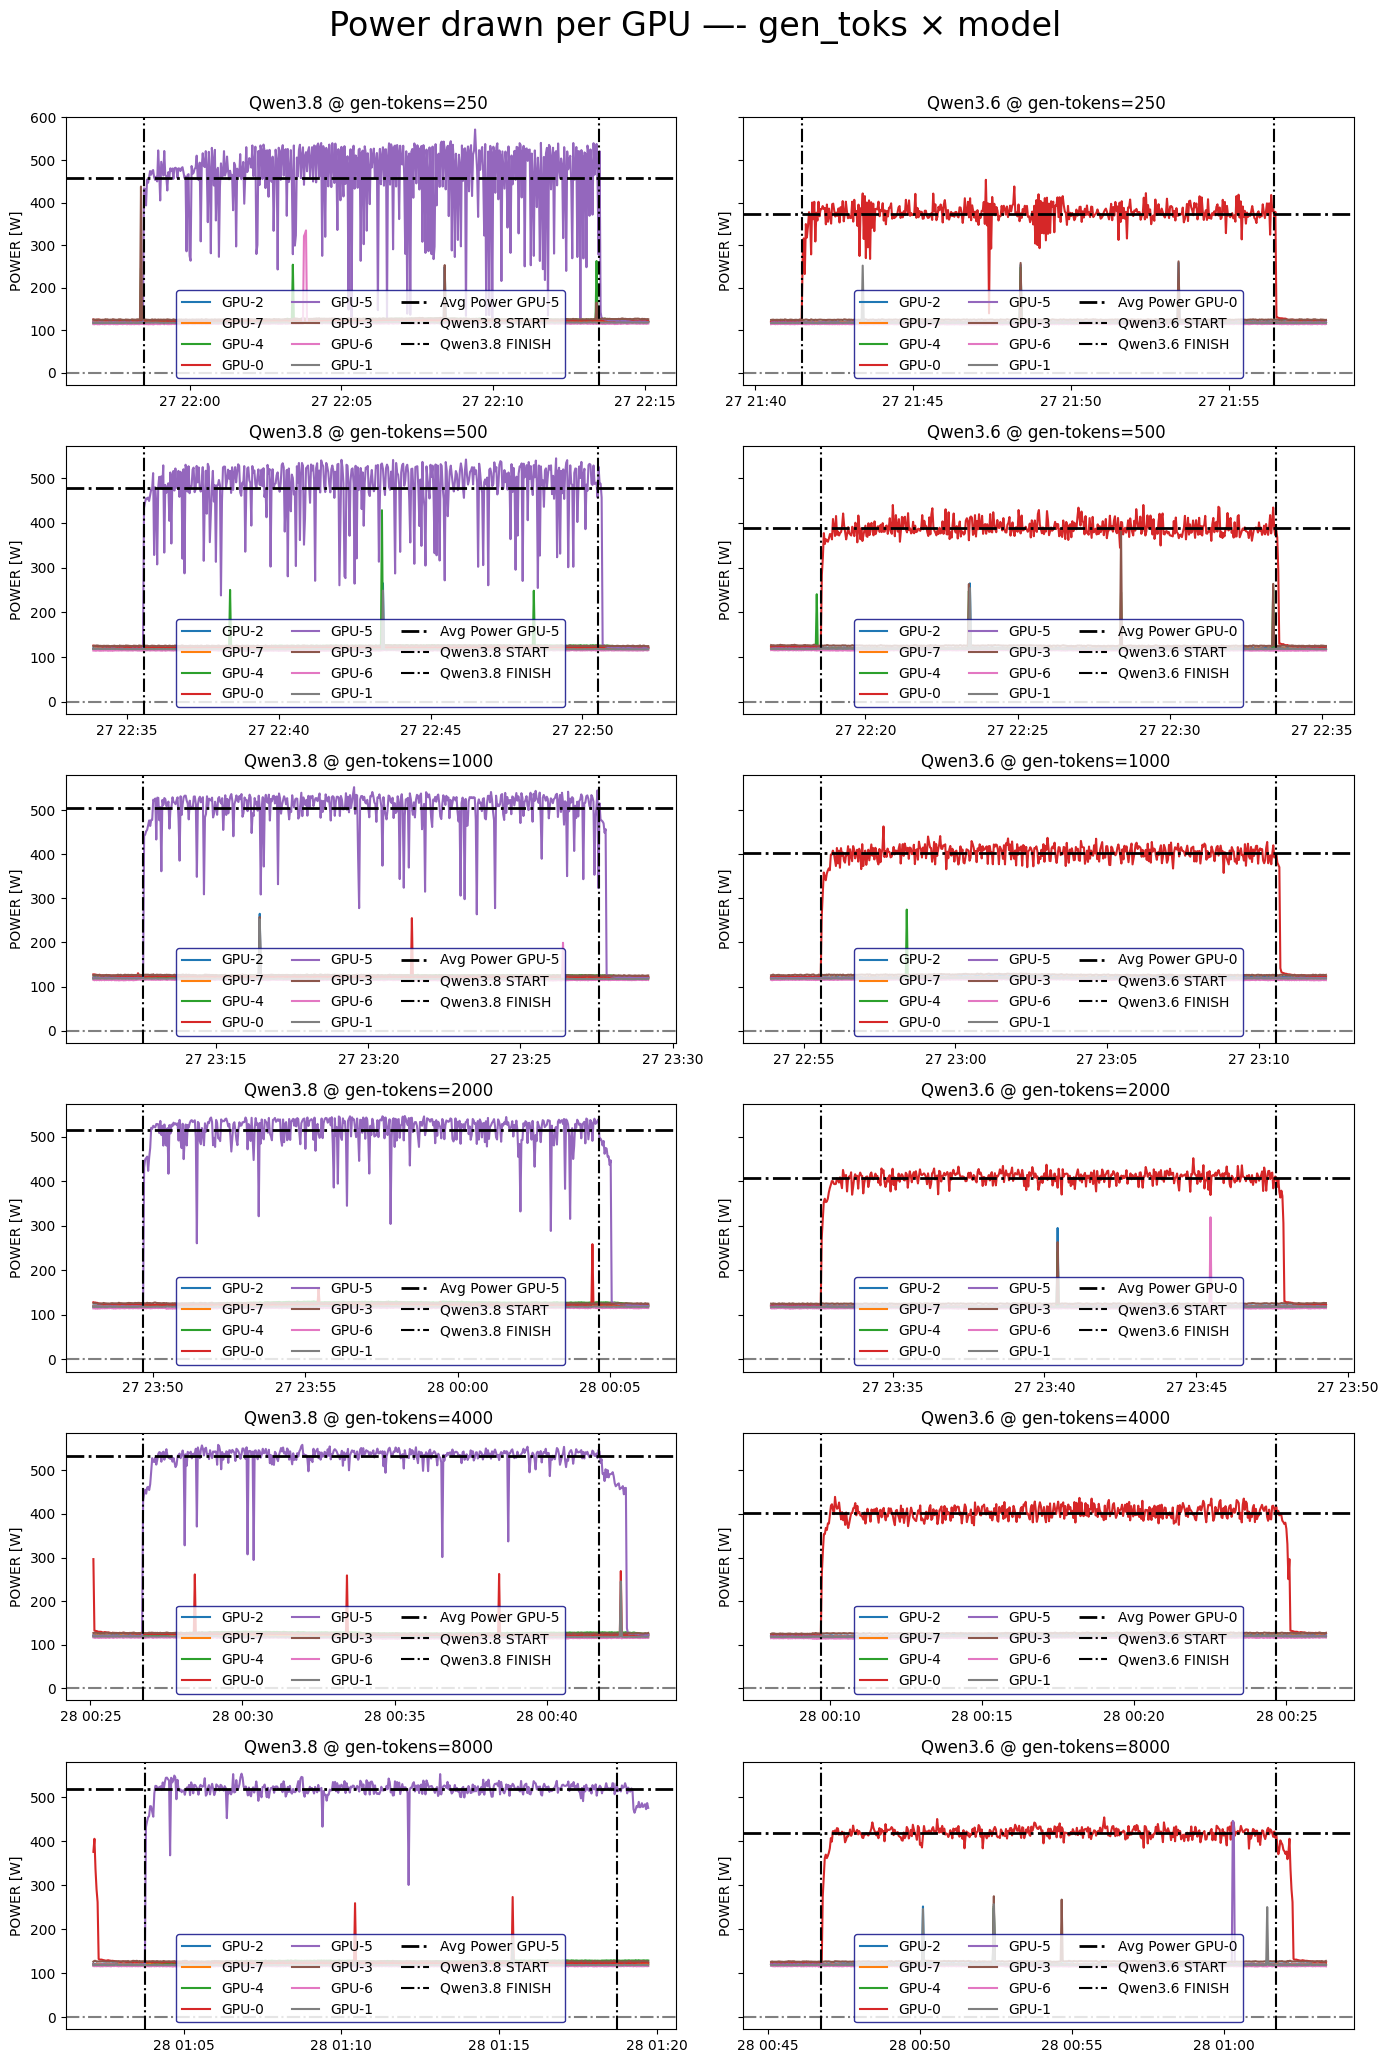

In [398]:

# --- setup grid ---
toks_list = sorted([int(x) for x in LCST[MODELS[0]].keys()])          # chiavi gen_toks (stesse per tutti)
toks_list = [str(x) for x in toks_list]
n_rows, n_cols = len(toks_list), len(MODELS)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(14, 3.5 * n_rows),
                         sharex=False,
                         sharey="row")

# flatten axes se n_rows == 1 (altrimenti 2D array)
if n_rows == 1:
    axes = [axes]


# GPU's are indexed by 'index'
df = DB["nvidia_smi"]
# vediamo il primo processo:
for r, toks in enumerate(toks_list):
    for c,m in enumerate(MODELS):

        ax = axes[r][c] if n_rows > 1 else axes[c]
        proc = LCST[m][toks]
        start, finish = min(proc["Timestamp"]), max(proc["Timestamp"])
        # TODO RMME
        delta = 100 # Adding some pre and post process power usage data
        measures = df.filter(
            pl.col("Timestamp").is_between(start - delta, finish + delta, closed="none")
        )

        max_avg_power = -1          # Tracking the max usage of the gpu
        inactive_gpus_avg_power = 0
        for gpu_index in set(measures["index"]):
            subm = measures.filter(pl.col("index") == gpu_index)
            ax.plot(subm["Datetime"], subm["power_draw"], label=f"GPU-{gpu_index}")
            # Calculate mean power draw DURING BENCHMARK ONLY
            subm_bench = subm.filter(
                pl.col("Timestamp").is_between(start, finish, closed="none")
            )
            # TODO: molto più elegante sommare le energie e dividere per ∆T (anhce se misure di potenza ≈ equidistanti)
            usage = subm_bench["power_draw"].mean()
            if usage > max_avg_power:
                # ADD TO RESULTS
                RESULTS[m][toks]["index_GPU"] = gpu_index
                max_avg_power = usage
            else:
                inactive_gpus_avg_power += subm["power_draw"].mean()
        # ADD TO RESULTS
        RESULTS[m][toks]["avg_power_active_GPU"] = max_avg_power
        RESULTS[m][toks]["avg_power_inactive_GPUS"] = inactive_gpus_avg_power
        

        ax.axhline(0, color="gray", ls="-.")
        ax.axhline(max_avg_power, ls="-.", lw=2, color="black", label=f"Avg Power GPU-{RESULTS[m][toks]["index_GPU"]}")
        # plotting start and finish times of the benchmark
        ax.axvline(datetime.fromtimestamp(start, timezone.utc), label=f"{m} START", color='black', ls="-.")
        ax.axvline(datetime.fromtimestamp(finish, timezone.utc), label=f"{m} FINISH", color='black', ls="-.")
        ax.set_ylabel(f"POWER [W]") # TODO: confirm it is in Watts
        ax.set_title(f"{m} @ gen-tokens={toks} ")
        # TODO: sort legend
        #RMME--ax.legend(loc="lower center", ncols=3, fontsize="medium", edgecolor='navy')
        ax.legend(fontsize="medium", loc="lower center", ncols=3, edgecolor="navy")

plt.suptitle("Power drawn per GPU —- gen_toks × model", fontsize=24)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


# Active GPU usage <br>
### from nvidia_smi.utilization_gpu

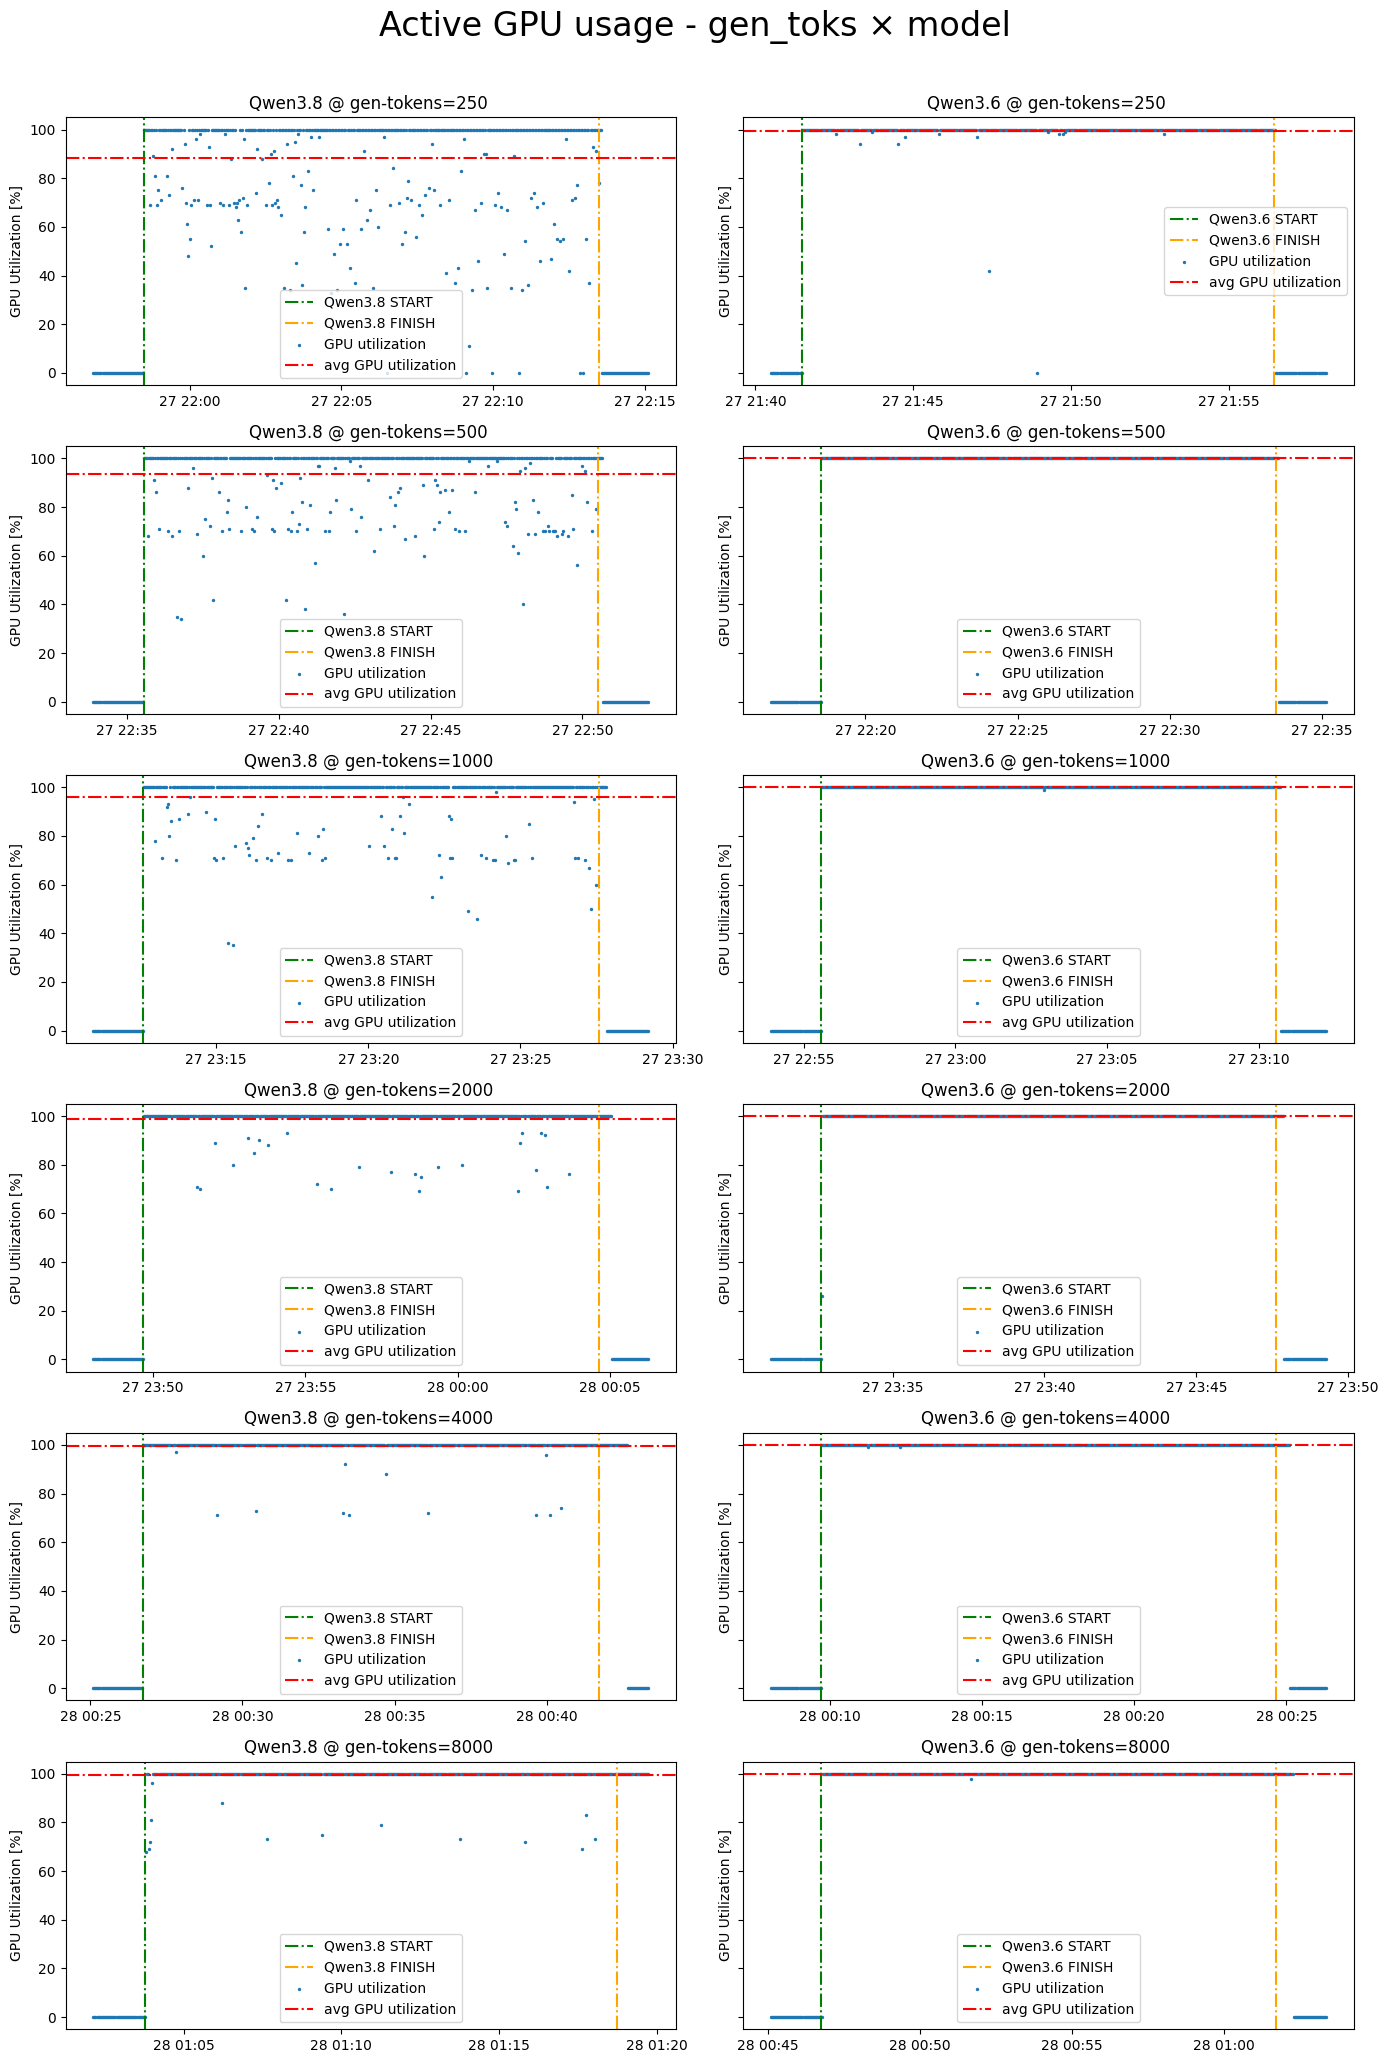

In [399]:
# --- setup grid ---
toks_list = sorted([int(x) for x in LCST[MODELS[0]].keys()])          # chiavi gen_toks (stesse per tutti)
toks_list = [str(x) for x in toks_list]
n_rows, n_cols = len(toks_list), len(MODELS)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(14, 3.5 * n_rows),
                         sharex=False,
                         sharey="row"
                        )

# flatten axes se n_rows == 1 (altrimenti 2D array)
if n_rows == 1:
    axes = [axes]

for r, toks in enumerate(toks_list):
    for c, m in enumerate(MODELS):
        ax = axes[r][c] if n_rows > 1 else axes[c]
        
        gpu_index = RESULTS[m][toks]["index_GPU"]
        proc = LCST[m][toks]
        df = DB["nvidia_smi"]
        start, finish = min(proc["Timestamp"]), max(proc["Timestamp"])
        delta = 100 # Adding some pre and post process power usage data
        df = df.filter(pl.col("index") == gpu_index)
        df = df.filter(pl.col("Timestamp").is_between(start - delta, finish + delta, closed="none"))

        start_dt = datetime.fromtimestamp(start, timezone.utc)
        finish_dt = datetime.fromtimestamp(finish, timezone.utc)
        ax.axvline(start_dt, label=f"{m} START", color='green', ls="-.")
        ax.axvline(finish_dt, label=f"{m} FINISH", color='orange', ls="-.")
        ax.scatter(df["Datetime"], df["utilization_gpu"], s=2.0, label="GPU utilization")

        df = df.filter(pl.col("Timestamp").is_between(start, finish, closed="none"))
        avg_gpu_utilization = df["utilization_gpu"].mean()
        # ADD TO RESULTS
        RESULTS[m][toks]["avg_gpu_utilization"] = avg_gpu_utilization

        ax.axhline(avg_gpu_utilization, color="r", ls="-.",lw=1.5, label=f"avg GPU utilization")
        ax.set_ylabel("GPU Utilization [%]")
        ax.set_title(f"{m} @ gen-tokens={toks} ")
        ax.legend()

plt.suptitle("Active GPU usage - gen_toks × model", fontsize=24)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# COMPLETION TOKENS / s

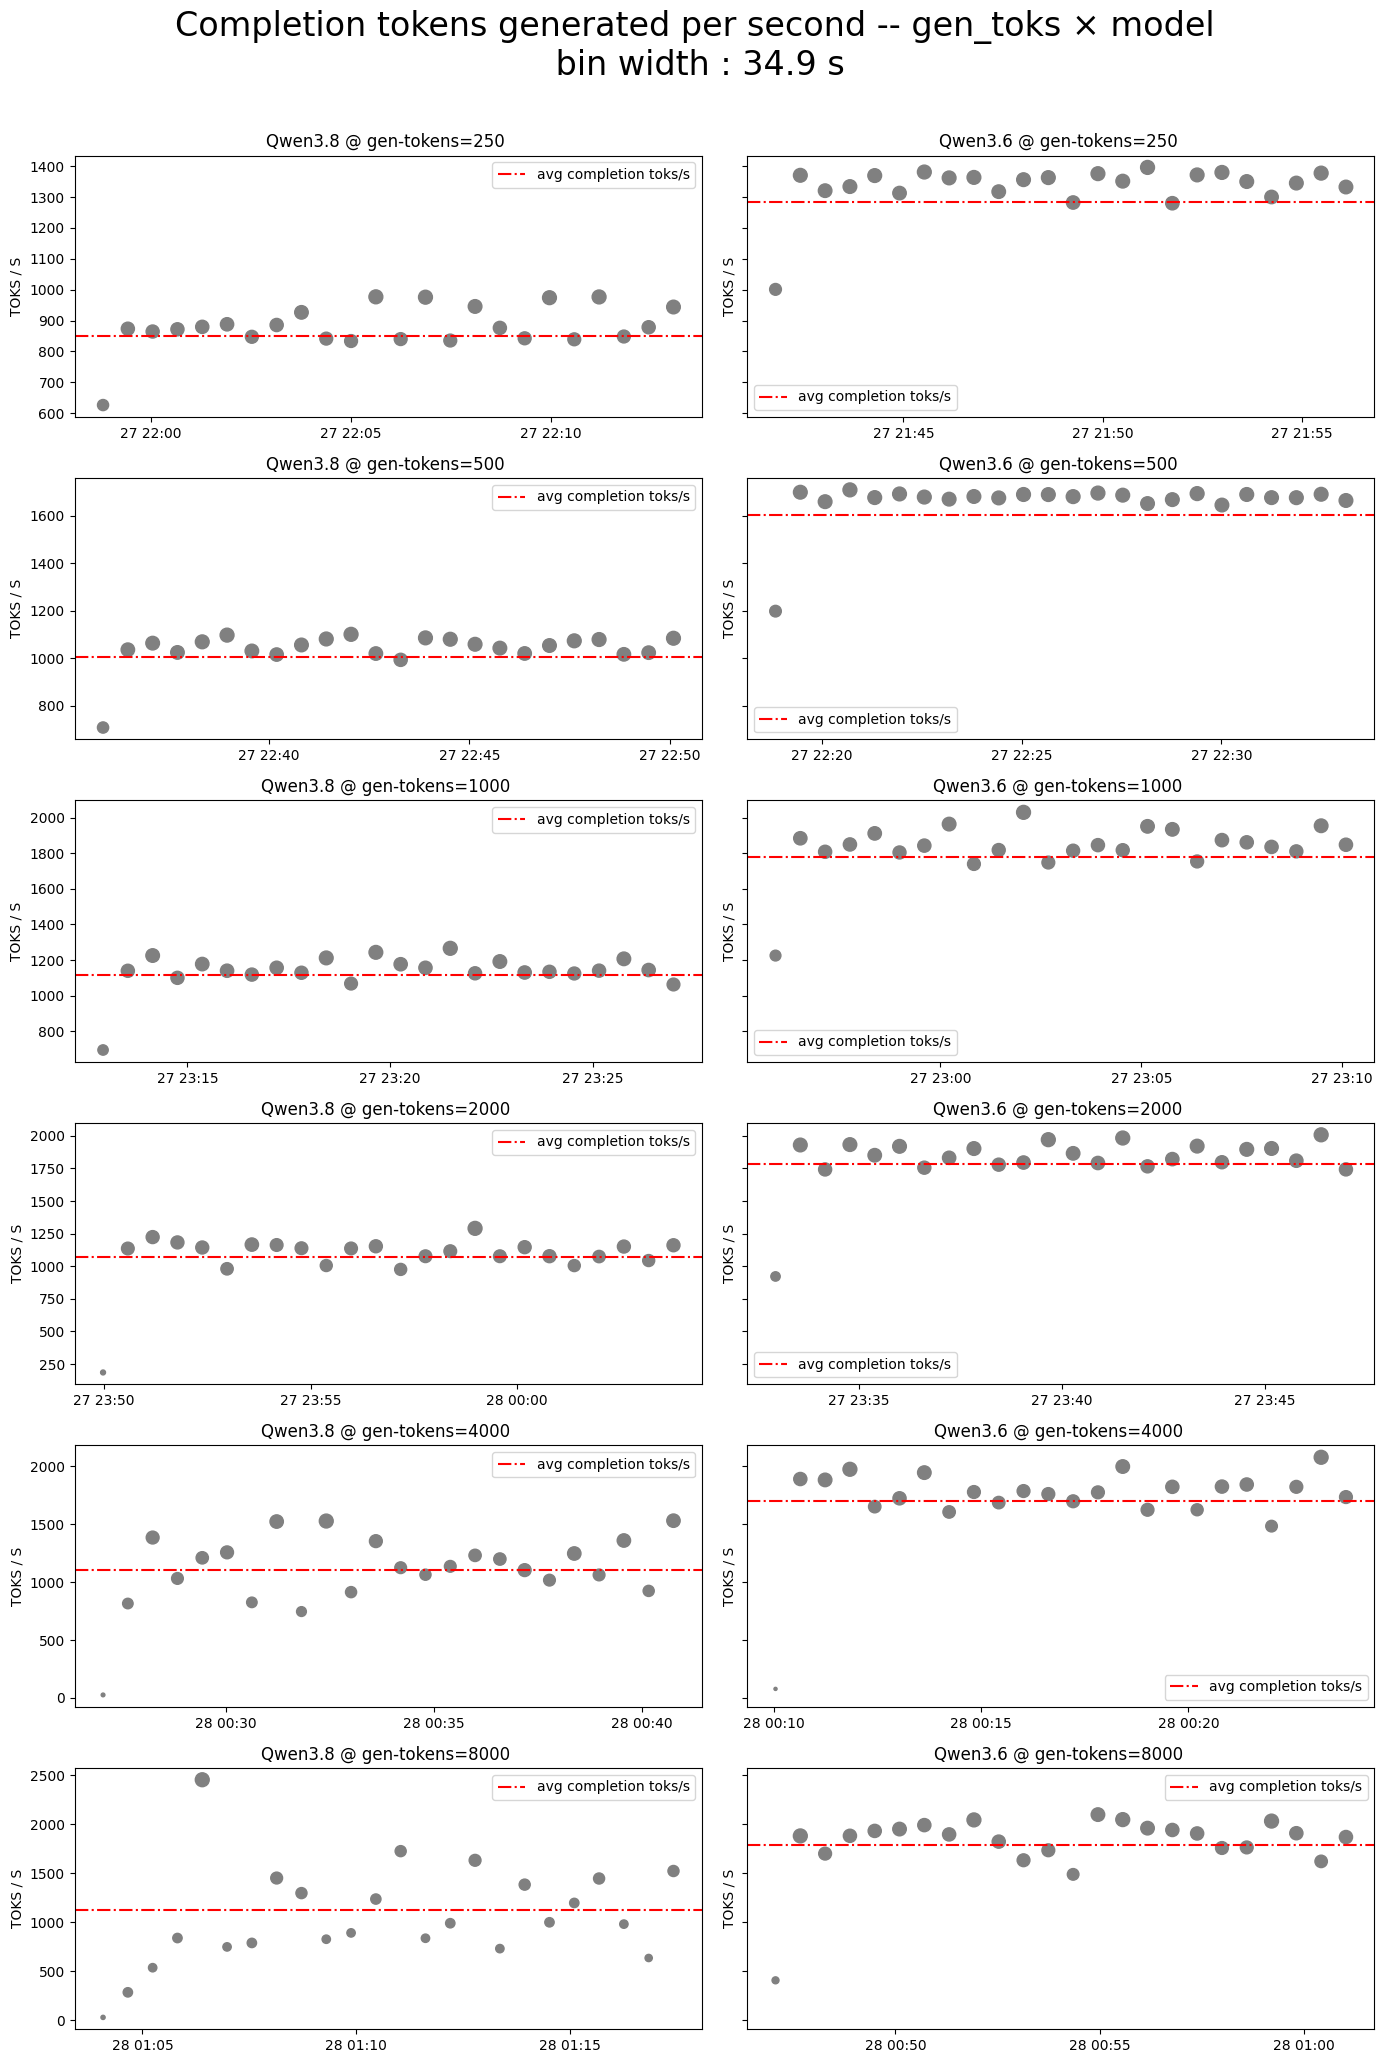

In [400]:
# --- setup grid ---
toks_list = sorted([int(x) for x in LCST[MODELS[0]].keys()])          # chiavi gen_toks (stesse per tutti)
toks_list = [str(x) for x in toks_list]
n_rows, n_cols = len(toks_list), len(MODELS)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(14, 3.5 * n_rows),
                         sharex=False,
                         sharey="row"
                        )

# flatten axes se n_rows == 1 (altrimenti 2D array)
if n_rows == 1:
    axes = [axes]

for r, toks in enumerate(toks_list):
    for c, m in enumerate(MODELS):
        ax = axes[r][c] if n_rows > 1 else axes[c]
        
        df = TOKS_STATS[m][toks]
        nbins = 25
        start, finish = df["t_start"].min(), df["t_start"].max()
        dt = (finish - start) / nbins
        # edges = { extrema of the bins }
        edges = np.linspace(start, finish, nbins)
        h_comp_toks = []
        req_counts = []
        for i, left in enumerate(edges[:-1]):
            right = edges[i + 1]
            in_bin = df.filter(pl.col("t_end").is_between(left,right,closed="right"))
            h_comp_toks.append( in_bin["completion_tokens"].sum() )
            req_counts.append(len(in_bin))
        centers = (edges[1:] + edges[:-1]) / 2.
        sizes = (100. / max(req_counts) ) * np.array(req_counts)
        # change unit to toks per second
        h_comp_toks = np.array(h_comp_toks) / dt
        centers = [datetime_from_timestamp(c) for c in centers]
        ax.scatter(centers, h_comp_toks, c='grey', s=sizes)
        
        # TOTAL COMPLETION TOKENS / TIME
        total_toks = df["completion_tokens"].sum()
        avg_toks_s = total_toks / (finish-start)
        # ADD RESULTS
        RESULTS[m][toks]["total_completion_tokens"] = total_toks
        RESULTS[m][toks]["avg_completion_toks_s"] = avg_toks_s
        ax.axhline(avg_toks_s, c="r", ls="-.", label="avg completion toks/s")
        ax.set_title(f"{m} @ gen-tokens={toks} ")
        ax.set_ylabel(f"TOKS / S")
        ax.legend()
        

plt.suptitle(f"Completion tokens generated per second -- gen_toks × model\n bin width : {dt:.1f} s", fontsize=24)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# DIFFERENCES IN TOKS / S BETWEEN MODELS

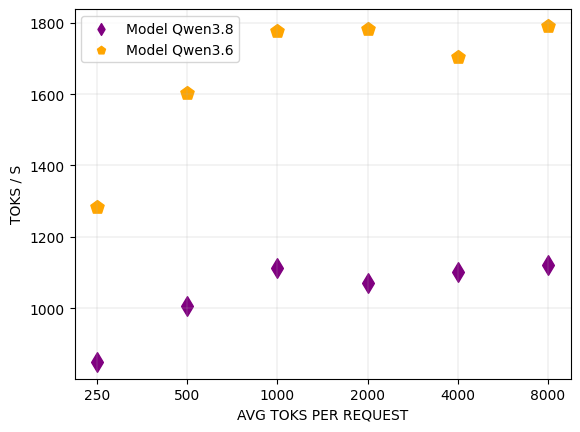

In [401]:
markers = ["d", "p"]
colors = ['purple', 'orange']
for c, m in enumerate(MODELS):
    marker = markers[c]
    color = colors[c]
    for r, toks in enumerate(toks_list):
        plt.scatter(toks,RESULTS[m][toks]["avg_completion_toks_s"], c=color, marker=marker, s=100)
        if r == 0:
            # add label
            plt.scatter([],[],c=color,marker=marker, label=f"Model {m}")
    
plt.xlabel("AVG TOKS PER REQUEST")
plt.ylabel("TOKS / S")
plt.legend()
plt.grid(lw=0.2)
plt.show()


# Active GPU energy per tokens generated

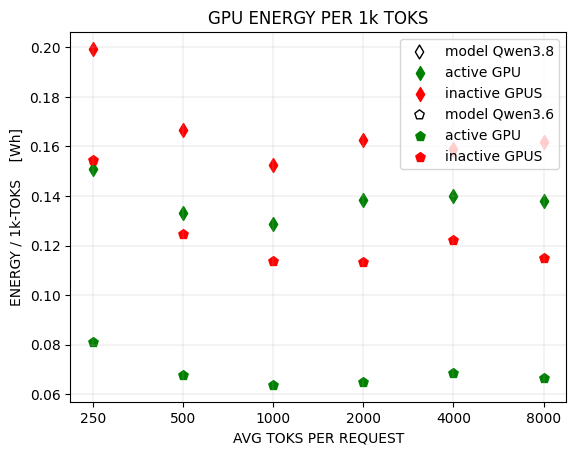

In [402]:
markers = ["d", "p"]
# psu_id="0" contains the sum over psu_id={1,2,3,4,5,6}
ipmi_pow = DB["ipmi_power"].filter((pl.col("psu_id") == "0") & (pl.col("unit") == "W"))


for j, m in enumerate(MODELS):
    marker = markers[j]
    plt.scatter([],[],marker=marker, color='black', facecolors='none',label=f"model {m}", s=50)
    for toks in GEN_TOKENS:
        proc = LCST[m][toks]
        start, finish = proc["Timestamp"].min(), proc["Timestamp"].max()
        duration = finish - start   # seconds
        # [Watt * (duration[s]) / 3600][Wh] / [TOTAL_TOKS / 1000] === [Watt / (3.6 * TOTAL_TOKS)] [Wh]
        active = RESULTS[m][toks]["avg_power_active_GPU"] * (duration) / (3.6 * RESULTS[m][toks]["total_completion_tokens"])
        inactive = RESULTS[m][toks]["avg_power_inactive_GPUS"] * (duration) / (3.6 * RESULTS[m][toks]["total_completion_tokens"])
        # Integrating this way is ok because ipmi_power measures are evenly distributed
        avg_ipmi_power = ipmi_pow.filter(pl.col("Timestamp").is_between(start, finish, closed="right"))["value"].mean()
        ipmi_energy_p1ktoks = avg_ipmi_power * (duration) / (3.6 * RESULTS[m][toks]["total_completion_tokens"])
        plt.scatter(toks, active,marker=marker, c="green", s=50)
        plt.scatter(toks, inactive,marker=marker, c="red", s=50)
        # ADD RESULTS
        RESULTS[m][toks]["active_gpu_energy_per_1ktoks"] = active
        RESULTS[m][toks]["inactive_gpu_energy_per_1ktoks"] = inactive
        RESULTS[m][toks]["ipmi_energy_per_1ktoks"] = ipmi_energy_p1ktoks
        
    plt.scatter([],[],marker=marker, c="green", s=50,label="active GPU")
    plt.scatter([],[],marker=marker, c="red", s=50,label="inactive GPUS")
plt.ylabel("ENERGY / 1k-TOKS    [Wh]")
plt.xlabel("AVG TOKS PER REQUEST")
plt.title("GPU ENERGY PER 1k TOKS")
plt.legend()
plt.grid(lw=0.2)
plt.show()



# System energy per 1000 tokens

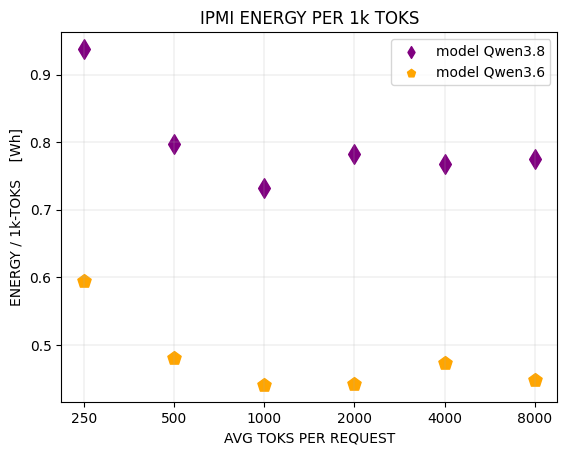

In [403]:
markers = ["d", "p"]
colors = ['purple', 'orange']
for j, m in enumerate(MODELS):
    for k, toks in enumerate(GEN_TOKENS):
        color = colors[j]
        marker = markers[j]
        val = RESULTS[m][toks]["ipmi_energy_per_1ktoks"]
        plt.scatter(toks, val, c=color, marker=marker, s=100)
        if k == 0:
            plt.scatter([],[],c=color, marker=marker,label=f"model {m}")

plt.ylabel("ENERGY / 1k-TOKS    [Wh]")
plt.xlabel("AVG TOKS PER REQUEST")
plt.title("IPMI ENERGY PER 1k TOKS")
plt.legend()
plt.grid(lw=0.2)
plt.show()

## MANCA 
## CPU ENERGY 
## | ADJ TOT ENERGY

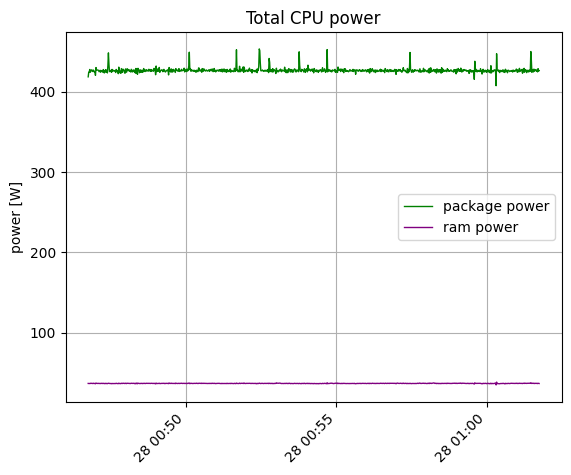

In [428]:

for m in MODELS:
    for toks in GEN_TOKENS:
        # ADD start, finish
        proc = LCST[m][toks]
        start, finish = proc["Timestamp"].min(), proc["Timestamp"].max()
        df = DB["cpu"].filter(pl.col("Timestamp").is_between(start, finish, closed="right"))
        dts = df["Timestamp"][:-1] - df["Timestamp"][1:]
        package_energy_Joule = (df["package_power_watt"][1:] * dts).sum()
        ram_energy_Joule = (df["ram_power_watt"][:-1] * dts).sum()
        cpu_total_energy_Wh = (package_energy_Joule + ram_energy_Joule) / 3600.
        RESULTS[m][toks]["cpu_total_enegy_Wh"] = cpu_total_energy_Wh
        RESULTS[m][toks]["cpu_energy_per_1ktoks"] = cpu_total_energy_Wh / RESULTS[m][toks]["total_completion_tokens"]

# plot of power
plt.title("Total CPU power")
plt.plot(df["Datetime"], df["package_power_watt"], c="green", lw=1, label="package power")
plt.plot(df["Datetime"], df["ram_power_watt"], c="purple", lw=1, label="ram power")
plt.ylabel("power [W]")
plt.legend()
plt.grid()
plt.xticks(rotation=45, ha="right")
plt.show()

# RISULTATI

In [ ]:
cols_map = {
    "Tokens/s":                     "avg_completion_toks_s",
    "Avg Active GPU Usage (%)":     "avg_gpu_utilization",
    "Active GPU Energy/1k TOKENS (Wh)":    "active_gpu_energy_per_1ktoks",
    "Inactive GPU Energy/1k TOKENS (Wh)":  "inactive_gpu_energy_per_1ktoks",
    "System Energy/1k TOKENS (Wh)":        "ipmi_energy_per_1ktoks",
}

rows = []
for model, toks_dict in RESULTS.items():
    for toks, stats in toks_dict.items():
        rows.append(
            {"Model": model, "toks": toks, **{k: stats.get(v) for k, v in cols_map.items()}}
        )

table = pl.DataFrame(rows)
table = table.with_columns(pl.col("toks").cast(pl.Int64))
table = table.sort(["Model", "toks"], descending=[False, False])
table.write_csv("out-stats.txt")
print("Fatto:", table.shape)
print(table.filter(pl.col("Model") == "Qwen3.6"))
print(table.filter(pl.col("Model") == "Qwen3.8"))

Fatto: (12, 7)
shape: (6, 7)
┌─────────┬──────┬─────────────┬───────────────────┬──────────────┬──────────────────┬─────────────┐
│ Model   ┆ toks ┆ Tokens/s    ┆ Avg Active GPU    ┆ Active GPU   ┆ Inactive GPU     ┆ System      │
│ ---     ┆ ---  ┆ ---         ┆ Usage (%)         ┆ Energy/1k    ┆ Energy/1k TOKENS ┆ Energy/1k   │
│ str     ┆ i64  ┆ f64         ┆ ---               ┆ TOKENS (W…   ┆ …                ┆ TOKENS (Wh) │
│         ┆      ┆             ┆ f64               ┆ ---          ┆ ---              ┆ ---         │
│         ┆      ┆             ┆                   ┆ f64          ┆ f64              ┆ f64         │
╞═════════╪══════╪═════════════╪═══════════════════╪══════════════╪══════════════════╪═════════════╡
│ Qwen3.6 ┆ 250  ┆ 1282.620751 ┆ 99.578125         ┆ 0.081213     ┆ 0.154683         ┆ 0.595084    │
│ Qwen3.6 ┆ 500  ┆ 1602.224304 ┆ 100.0             ┆ 0.067655     ┆ 0.124832         ┆ 0.481139    │
│ Qwen3.6 ┆ 1000 ┆ 1776.066452 ┆ 99.997773         ┆ 0.06368  